In [15]:
import pandas as pd

data = pd.read_excel("../data/pakistan_aqi.xlsx")



In [16]:
pm25_data = data[data["Type"] == "PM 2.5"]

pm25_data.head()
pm25_data.shape

(1367, 4)

In [17]:
pm25_data.to_csv("../data/pakistan_pm25_clean.csv", index=False)

In [18]:
pm25_data.to_csv("../data/pakistan_pm25_clean.csv", index=False)

In [19]:
data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


In [20]:
data.columns

Index(['Date', 'City', 'Type', 'Count'], dtype='object')

In [21]:
data["Type"].value_counts()


Type
PM 2.5    1367
Name: count, dtype: int64

In [22]:
pm25_data = data[data["Type"] == "PM 2.5"]

pm25_data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


In [23]:
pm25_data.shape

(1367, 4)

In [24]:
pm25_data["City"].value_counts()

City
Islamabad    358
Lahore       347
Karachi      333
Peshawar     329
Name: count, dtype: int64

In [25]:
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])
pm25_data.dtypes

Date     datetime64[ns]
City             object
Type             object
Count            object
dtype: object

In [26]:
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])
pm25_data.dtypes


Date     datetime64[ns]
City             object
Type             object
Count            object
dtype: object

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

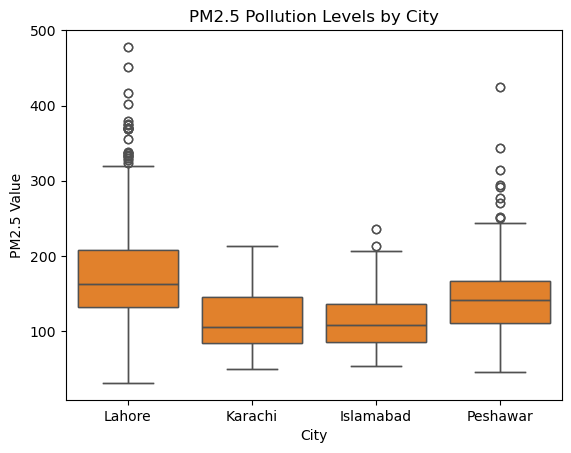

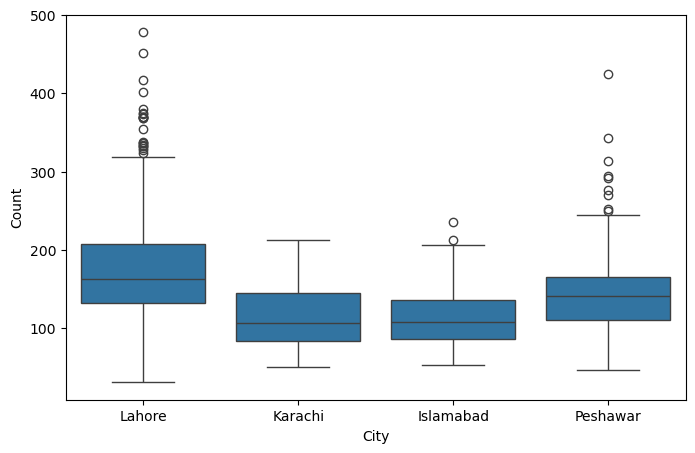

In [28]:

pm25_data["Count"] = pm25_data["Count"].replace("-", None)


pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])


pm25_data = pm25_data.dropna(subset=["Count"])


pm25_data.dtypes


sns.boxplot(x="City", y="Count", data=pm25_data)

sns.boxplot(x="City", y="Count", data=pm25_data)

plt.title("PM2.5 Pollution Levels by City")
plt.xlabel("City")
plt.ylabel("PM2.5 Value")


plt.figure(figsize=(8,5))

sns.boxplot(x="City", y="Count", data=pm25_data)



plt.savefig("../images/pollution_by_city.png")

plt.show()

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
data = pd.read_excel("../data/pakistan_aqi.xlsx")
data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


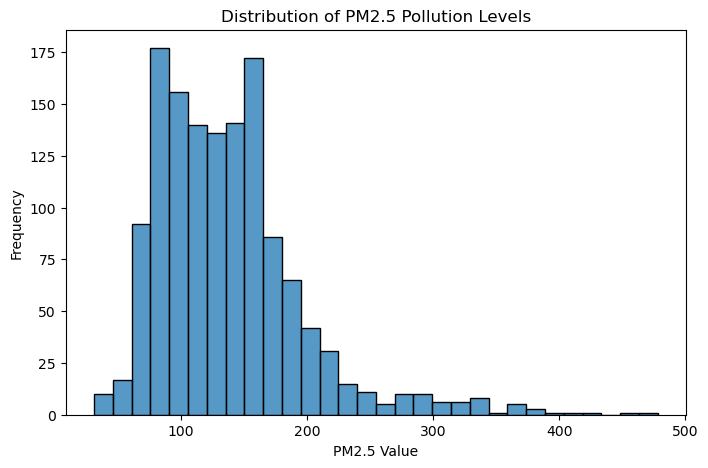

In [31]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 data
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert Date column to datetime
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean Count column
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])
pm25_data = pm25_data.dropna(subset=["Count"])

# Create histogram

plt.figure(figsize=(8,5))

sns.histplot(pm25_data["Count"], bins=30)

plt.title("Distribution of PM2.5 Pollution Levels")
plt.xlabel("PM2.5 Value")
plt.ylabel("Frequency")

plt.savefig("../images/pm25_distribution.png")

plt.show()

In [32]:
city_avg = pm25_data.groupby("City")["Count"].mean()

city_avg

City
Islamabad    113.853521
Karachi      113.655385
Lahore       178.612245
Peshawar     143.446483
Name: Count, dtype: float64

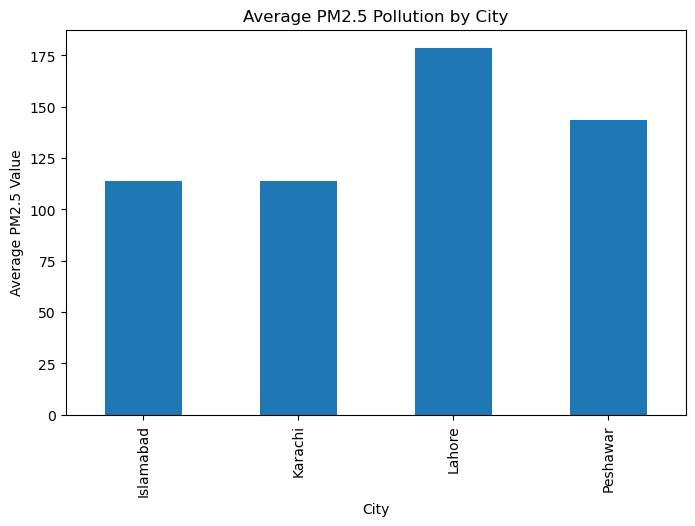

In [34]:
plt.figure(figsize=(8,5))

city_avg.plot(kind="bar")

plt.title("Average PM2.5 Pollution by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5 Value")

plt.savefig("../images/avg_pollution_by_city.png")

plt.show()

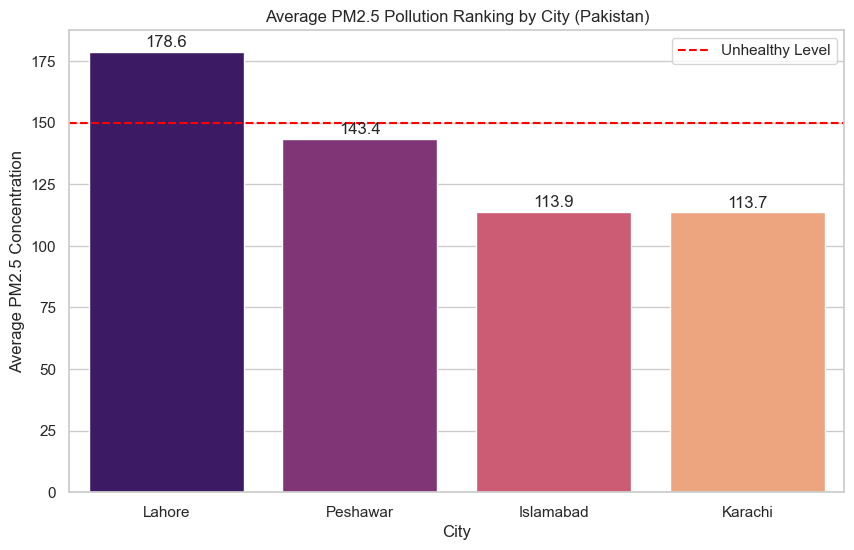

In [37]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
# Calculate average pollution per city
city_avg = pm25_data.groupby("City")["Count"].mean()

# Sort cities by pollution level
city_avg_sorted = city_avg.sort_values(ascending=False)

city_avg_sorted
ax = sns.barplot(
    x=city_avg_sorted.index,
    y=city_avg_sorted.values,
    hue=city_avg_sorted.index,   # assign hue
    palette="magma",
    legend=False                 # hide duplicate legend
)

# Add value labels
for i, value in enumerate(city_avg_sorted.values):
    ax.text(i, value + 2, f"{value:.1f}", ha="center")

# Reference line
plt.axhline(150, color="red", linestyle="--", label="Unhealthy Level")

plt.title("Average PM2.5 Pollution Ranking by City (Pakistan)")
plt.xlabel("City")
plt.ylabel("Average PM2.5 Concentration")

plt.legend()

plt.savefig("../images/pollution_city_ranking_advanced.png")

plt.show()


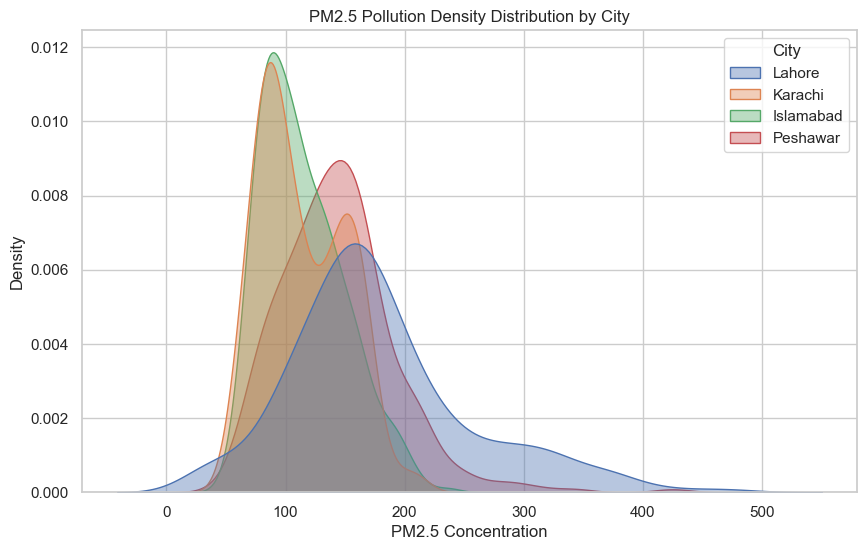

In [38]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

sns.kdeplot(
    data=pm25_data,
    x="Count",
    hue="City",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("PM2.5 Pollution Density Distribution by City")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Density")

plt.savefig("../images/pollution_density_city.png")

plt.show()

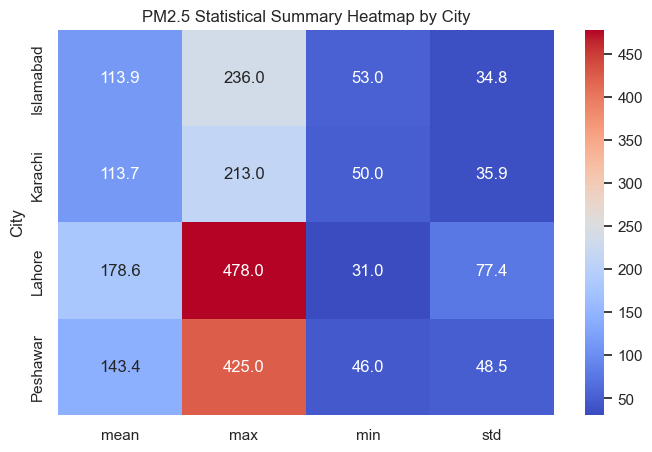

In [39]:
# Create statistical summary
city_stats = pm25_data.groupby("City")["Count"].agg(["mean","max","min","std"])

plt.figure(figsize=(8,5))

sns.heatmap(
    city_stats,
    annot=True,
    cmap="coolwarm",
    fmt=".1f"
)

plt.title("PM2.5 Statistical Summary Heatmap by City")

plt.savefig("../images/pollution_heatmap_city.png")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18168\2568707378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


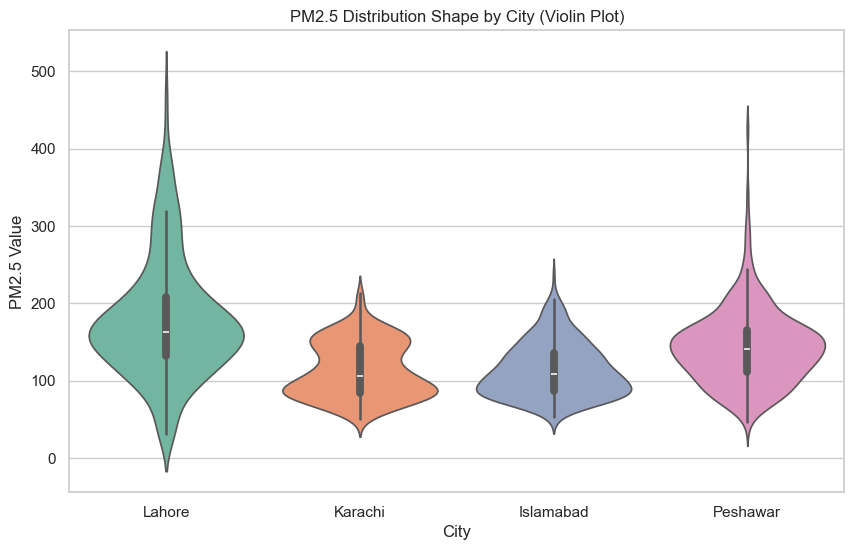

In [40]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

sns.violinplot(
    data=pm25_data,
    x="City",
    y="Count",
    palette="Set2"
)

plt.title("PM2.5 Distribution Shape by City (Violin Plot)")
plt.xlabel("City")
plt.ylabel("PM2.5 Value")

plt.savefig("../images/pollution_violin_city.png")

plt.show()

<Figure size 1000x600 with 0 Axes>

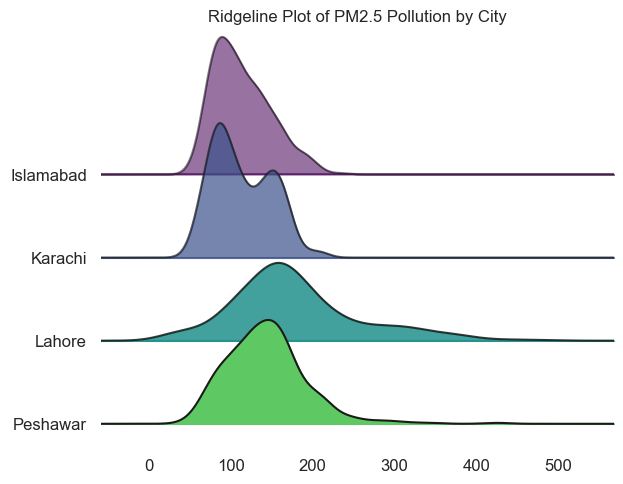

In [42]:
import joypy
plt.figure(figsize=(10,6))

joypy.joyplot(
    data=pm25_data,
    by="City",
    column="Count",
    colormap=plt.cm.viridis,
    fade=True
)

plt.title("Ridgeline Plot of PM2.5 Pollution by City")

plt.savefig("../images/pollution_ridgeline_city.png")

plt.show()

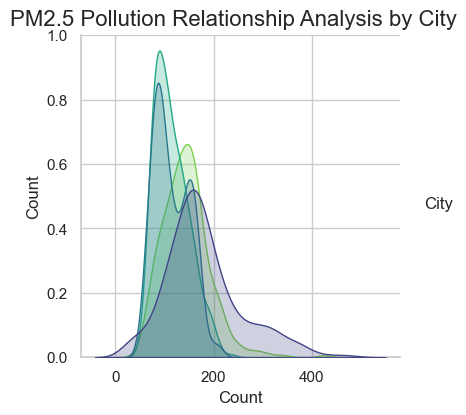

In [45]:
pairplot_data = pm25_data[["City", "Count"]]

pairplot_data.head()
sns.set_theme(style="whitegrid")

pairplot = sns.pairplot(
    pairplot_data,
    hue="City",
    palette="viridis",
    height=4,          # controls size of each subplot
    diag_kind="kde",   # smoother distribution
    plot_kws={"alpha":0.6, "s":60}  # marker transparency + size
)

pairplot.fig.suptitle(
    "PM2.5 Pollution Relationship Analysis by City",
    y=1.02,
    fontsize=16
)

pairplot.savefig("../images/pollution_pairplot_city.png")

plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 data
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert Date column to datetime
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean pollution values
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])
pm25_data = pm25_data.dropna(subset=["Count"])

pm25_data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231.0
1,2019-05-11,Lahore,PM 2.5,171.0
2,2019-05-12,Lahore,PM 2.5,209.0
3,2019-05-13,Lahore,PM 2.5,188.0
4,2019-05-14,Lahore,PM 2.5,194.0


In [6]:
# Create daily PM2.5 time-series dataset
daily_pm25 = pm25_data.groupby("Date")["Count"].mean()

daily_pm25.head()

Date
2019-04-29    162.0
2019-04-30    124.0
2019-05-01     89.0
2019-05-02     87.0
2019-05-03     69.0
Name: Count, dtype: float64

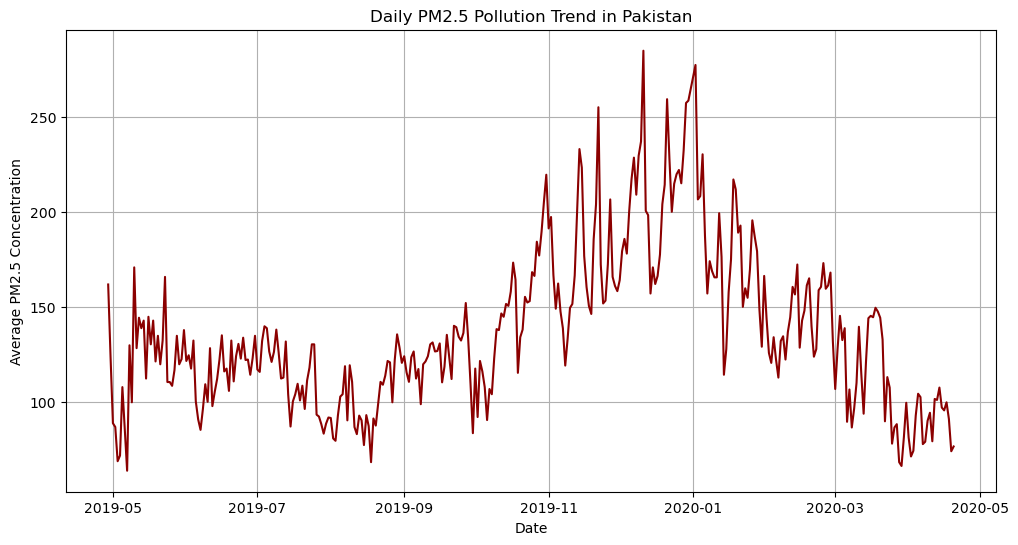

In [7]:
plt.figure(figsize=(12,6))

sns.lineplot(x=daily_pm25.index, y=daily_pm25.values, color="darkred")

plt.title("Daily PM2.5 Pollution Trend in Pakistan")
plt.xlabel("Date")
plt.ylabel("Average PM2.5 Concentration")

plt.grid(True)

plt.show()

In [8]:
city_daily_pm25 = pm25_data.groupby(["Date","City"])["Count"].mean().reset_index()

city_daily_pm25.head()

,Date,City,Count
0,2019-04-29,Islamabad,162.0
1,2019-04-30,Islamabad,124.0
2,2019-05-01,Islamabad,89.0
3,2019-05-02,Islamabad,87.0
4,2019-05-03,Islamabad,69.0


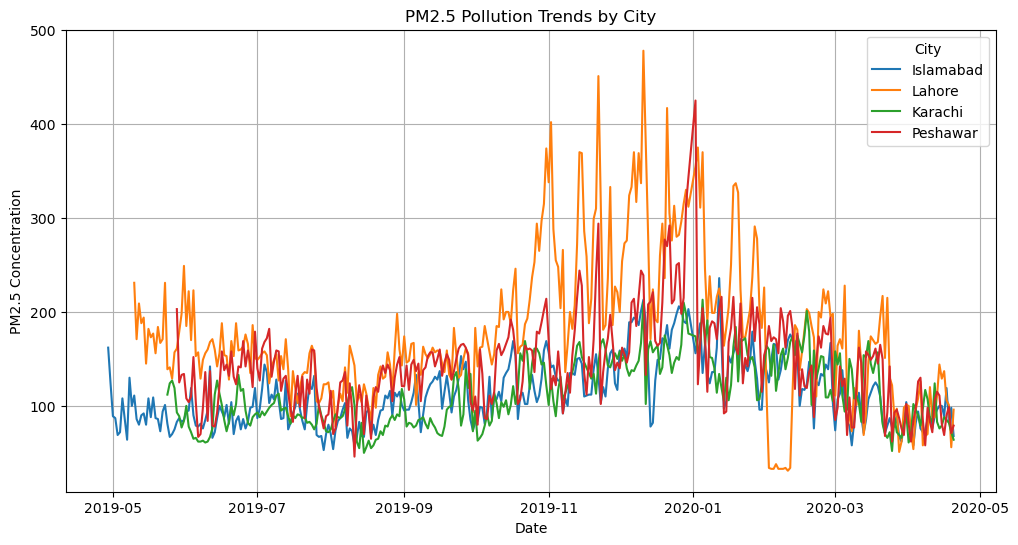

In [10]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=city_daily_pm25,
    x="Date",
    y="Count",
    hue="City"
)

plt.title("PM2.5 Pollution Trends by City")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")

plt.grid(True)

plt.savefig("../images/pm25_city_trends.png")

plt.show()

In [11]:
rolling_pm25 = daily_pm25.rolling(window=7).mean()

rolling_pm25.head()

Date
2019-04-29   NaN
2019-04-30   NaN
2019-05-01   NaN
2019-05-02   NaN
2019-05-03   NaN
Name: Count, dtype: float64

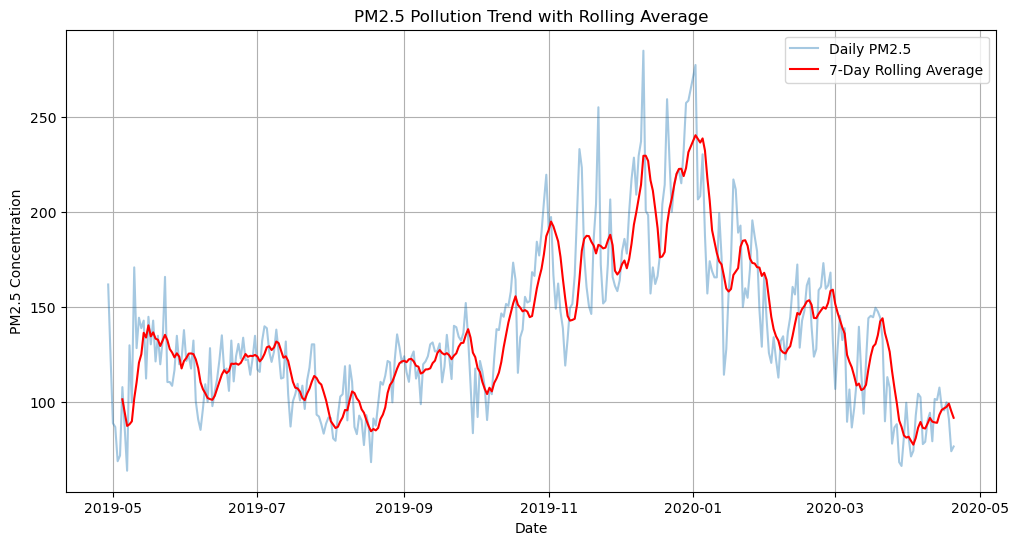

In [12]:
plt.figure(figsize=(12,6))

sns.lineplot(x=daily_pm25.index, y=daily_pm25.values, label="Daily PM2.5", alpha=0.4)

sns.lineplot(x=rolling_pm25.index, y=rolling_pm25.values, color="red", label="7-Day Rolling Average")

plt.title("PM2.5 Pollution Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")

plt.grid(True)

plt.savefig("../images/pm25_rolling_average.png")

plt.show()

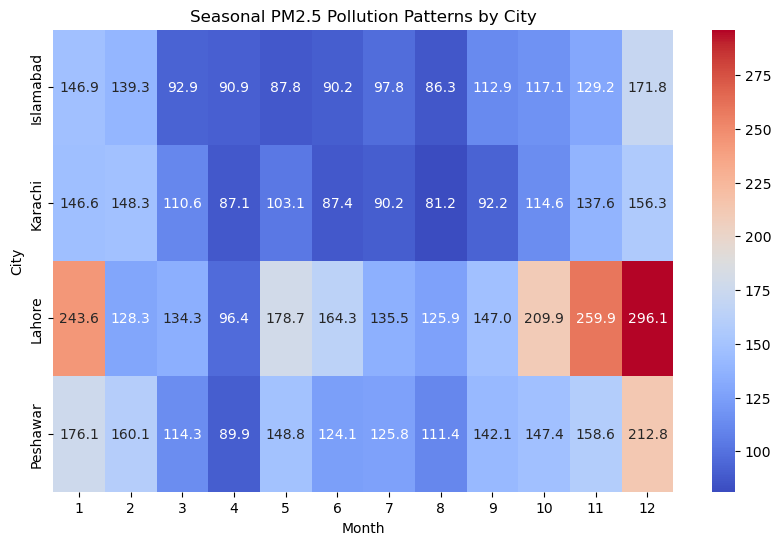

In [15]:
pm25_data["Month"] = pm25_data["Date"].dt.month

pm25_data.head()

monthly_city_pm25 = pm25_data.groupby(["City","Month"])["Count"].mean().unstack()

monthly_city_pm25

plt.figure(figsize=(10,6))

sns.heatmap(
    monthly_city_pm25,
    cmap="coolwarm",
    annot=True,
    fmt=".1f"
)

plt.title("Seasonal PM2.5 Pollution Patterns by City")
plt.xlabel("Month")
plt.ylabel("City")

plt.savefig("../images/pm25_seasonal_heatmap.png")

plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 records
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert Date column
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean pollution values
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])
pm25_data = pm25_data.dropna(subset=["Count"])

pm25_data.head()


pm25_data["Year"] = pm25_data["Date"].dt.year
pm25_data["Month"] = pm25_data["Date"].dt.month
pm25_data["Day"] = pm25_data["Date"].dt.day
pm25_data["Weekday"] = pm25_data["Date"].dt.weekday

pm25_data.head()

pm25_data = pd.get_dummies(pm25_data, columns=["City"])

pm25_data.head()

,Date,Type,Count,Year,Month,Day,Weekday,City_Islamabad,City_Karachi,City_Lahore,City_Peshawar
0,2019-05-10,PM 2.5,231.0,2019,5,10,4,False,False,True,False
1,2019-05-11,PM 2.5,171.0,2019,5,11,5,False,False,True,False
2,2019-05-12,PM 2.5,209.0,2019,5,12,6,False,False,True,False
3,2019-05-13,PM 2.5,188.0,2019,5,13,0,False,False,True,False
4,2019-05-14,PM 2.5,194.0,2019,5,14,1,False,False,True,False


In [7]:
X = pm25_data.drop(columns=["Count","Date","Type"])
y = pm25_data["Count"]

X.head()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1080, 8)
Testing data: (270, 8)


In [11]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred[:10]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 34.24773776686413
RMSE: 46.0829748611744
R2 Score: 0.32832613268621225
